In [1]:
import os
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from data_loader import load_train_data, load_test_data
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import joblib
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
# 训练集：2022-01~2023-02
X_trains, X_tests, y_trains, y_tests = [], [], [], []
for month in [f"{year}-{str(m).zfill(2)}" for year in range(2022, 2024) for m in range(1, 13)]:
    if month >= "2023-03":
        break
    malicious_output_txt_path = f"/Data2/hxq/MalGuard/fea_ex/dataset_0129/malware_features_{month}.txt"
    benign_output_txt_path = f"/Data2/hxq/MalGuard/fea_ex/dataset_0129/benign_features_{month}.txt"
    X_train, X_test, y_train, y_test = load_train_data(malicious_output_txt_path, benign_output_txt_path)
    X_trains.append(X_train)
    X_tests.append(X_test)
    y_trains.append(y_train)
    y_tests.append(y_test)
X_train = np.vstack(X_trains)
y_train = np.hstack(y_trains)
X_test = np.vstack(X_tests)
y_test = np.hstack(y_tests)

In [3]:
from train_with_lime import train_with_progress_bar, load_sensitive_apis

sensitive_api_file = r"/Data2/hxq/MalGuard/API-call-graph/gpt_prompt_result_closeness_0129.json"
with open(sensitive_api_file, "r") as f:
    sensitive_apis = json.load(f)
sensitive_apis = load_sensitive_apis(sensitive_api_file) 

model_save_path = r"./models"
os.makedirs(model_save_path, exist_ok=True)

# NB
nb_model = GaussianNB()
train_with_progress_bar(nb_model, X_train, y_train, X_test, y_test, "Naive Bayes", model_save_path,
                        sensitive_apis, n_iter=100)

# MLP
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1, warm_start=True, random_state=42)
train_with_progress_bar(mlp_model, X_train, y_train, X_test, y_test, "Multi Layer Perceptron",
                        model_save_path, sensitive_apis, n_iter=500)

# RF
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
train_with_progress_bar(rf_model, X_train, y_train, X_test, y_test, "Random Forest", model_save_path,
                        sensitive_apis, n_iter=100)

# DT
dt_model = DecisionTreeClassifier(random_state=42)
train_with_progress_bar(dt_model, X_train, y_train, X_test, y_test, "Decision Tree", model_save_path,
                        sensitive_apis, n_iter=100)

Training Naive Bayes: 100%|██████████| 100/100 [00:01<00:00, 77.08iter/s]



Naive Bayes Results
              precision    recall  f1-score   support

         0.0    0.54841   0.99502   0.70710      1406
         1.0    0.97727   0.20716   0.34185      1453

    accuracy                        0.59461      2859
   macro avg    0.76284   0.60109   0.52448      2859
weighted avg    0.76637   0.59461   0.52147      2859

Naive Bayes saved to ./models/naive_bayes/naive_bayes_model.pkl


Training Multi Layer Perceptron: 100%|██████████| 500/500 [00:48<00:00, 10.28iter/s]



Multi Layer Perceptron Results
              precision    recall  f1-score   support

         0.0    0.98801   0.99644   0.99221      1406
         1.0    0.99653   0.98830   0.99240      1453

    accuracy                        0.99231      2859
   macro avg    0.99227   0.99237   0.99230      2859
weighted avg    0.99234   0.99231   0.99231      2859

Multi Layer Perceptron saved to ./models/multi_layer_perceptron/multi_layer_perceptron_model.pkl


Training Random Forest: 100%|██████████| 100/100 [01:15<00:00,  1.33iter/s]



Random Forest Results
              precision    recall  f1-score   support

         0.0    0.98526   0.99858   0.99188      1406
         1.0    0.99861   0.98555   0.99203      1453

    accuracy                        0.99196      2859
   macro avg    0.99193   0.99206   0.99195      2859
weighted avg    0.99204   0.99196   0.99196      2859

Random Forest saved to ./models/random_forest/random_forest_model.pkl


Training Decision Tree: 100%|██████████| 100/100 [00:11<00:00,  8.86iter/s]


Decision Tree Results
              precision    recall  f1-score   support

         0.0    0.98513   0.98933   0.98722      1406
         1.0    0.98963   0.98555   0.98759      1453

    accuracy                        0.98741      2859
   macro avg    0.98738   0.98744   0.98741      2859
weighted avg    0.98742   0.98741   0.98741      2859

Decision Tree saved to ./models/decision_tree/decision_tree_model.pkl


In [4]:
def test_model(model, X_test, y_test, model_name):
    """
    测试模型并打印 precision, recall, f1
    """
    print(f"\n{'='*50}")
    print(f"Testing {model_name}")
    print(f"{'='*50}")

    # 预测
    y_pred = model.predict(X_test)

    # 计算指标
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # 打印结果
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    # 详细分类报告
    print(f"\n{classification_report(y_test, y_pred, target_names=['Benign', 'Malicious'])}")

    return precision, recall, f1

In [5]:
# 从 models 目录加载已训练的模型并测试
models_dir = r'/Data2/hxq/MalGuard/model_training/models'

results = []

# 可加载的模型列表
model_files = [
    "naive_bayes",
    "decision_tree",
    "random_forest",
    "multi_layer_perceptron",
]

# 测试模型在2022-01~2024-03每个月的数据集上的表现
# 先加载所有模型为全局变量
print("Loading all models...")
models = {}
for model_file in model_files:
    model_path = os.path.join(models_dir, model_file, f"{model_file}_model.pkl")
    if os.path.exists(model_path):
        models[model_file] = joblib.load(model_path)
        print(f"  Loaded: {model_file}")


Loading all models...
  Loaded: naive_bayes
  Loaded: decision_tree
  Loaded: random_forest
  Loaded: multi_layer_perceptron


In [6]:
# 定义月份列表
months = [f"{year}-{str(m).zfill(2)}" for year in range(2022, 2025) for m in range(1, 13)]

# 存储结果的DataFrame
results = []

# 先循环模型，再循环月份
for model_file, model in models.items():
    model_name = model_file.replace("_", " ").title()
    print(f"\n{'#'*20} Testing {model_name} {'#'*20}")
    
    for month in months:
        if month > '2024-03':
            break  # 跳过2024-03之后的月份
        mal_data_path = f"/Data2/hxq/MalGuard/fea_ex/dataset_0129/malware_features_{month}.txt"
        ben_data_path = f"/Data2/hxq/MalGuard/fea_ex/dataset_0129/benign_features_{month}.txt"

        X_test, y_test = load_test_data(mal_data_path, ben_data_path)
        
        # 预测并计算指标
        y_pred = model.predict(X_test)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        results.append({
            "Model": model_name,
            "Month": month,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })
        
        print(f"  {month}: P={precision:.4f}, R={recall:.4f}, F1={f1:.4f}")

# 转换为DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("Results Summary:")
print("="*60)
print(results_df.to_string(index=False))

# 保存结果
results_df.to_csv("/Data2/hxq/MalGuard/model_training/monthly_results.csv", index=False)
print("\nResults saved to monthly_results.csv")


#################### Testing Naive Bayes ####################
  2022-01: P=0.9375, R=0.9286, F1=0.9282
  2022-02: P=0.7791, R=0.6042, F1=0.5306
  2022-03: P=0.9224, R=0.9130, F1=0.9126
  2022-04: P=1.0000, R=1.0000, F1=1.0000
  2022-05: P=0.9286, R=0.9167, F1=0.9161
  2022-06: P=0.8218, R=0.7232, F1=0.7003
  2022-07: P=0.8769, R=0.8367, F1=0.8323
  2022-08: P=0.2493, R=0.4974, F1=0.3322
  2022-09: P=0.7627, R=0.5484, F1=0.4327
  2022-10: P=0.6872, R=0.5329, F1=0.4117
  2022-11: P=0.8258, R=0.7633, F1=0.7513
  2022-12: P=0.7886, R=0.6681, F1=0.6295
  2023-01: P=0.8067, R=0.6849, F1=0.6502
  2023-02: P=0.7553, R=0.5761, F1=0.4861
  2023-03: P=0.7367, R=0.5538, F1=0.4478
  2023-04: P=0.7756, R=0.6333, F1=0.5790
  2023-05: P=0.8038, R=0.7143, F1=0.6916
  2023-06: P=0.5891, R=0.5217, F1=0.4103
  2023-07: P=0.7722, R=0.5814, F1=0.4925
  2023-08: P=0.6833, R=0.5606, F1=0.4723
  2023-09: P=0.7750, R=0.5909, F1=0.5087
  2023-10: P=0.7679, R=0.5667, F1=0.4665
  2023-11: P=0.6734, R=0.5811, F1=0

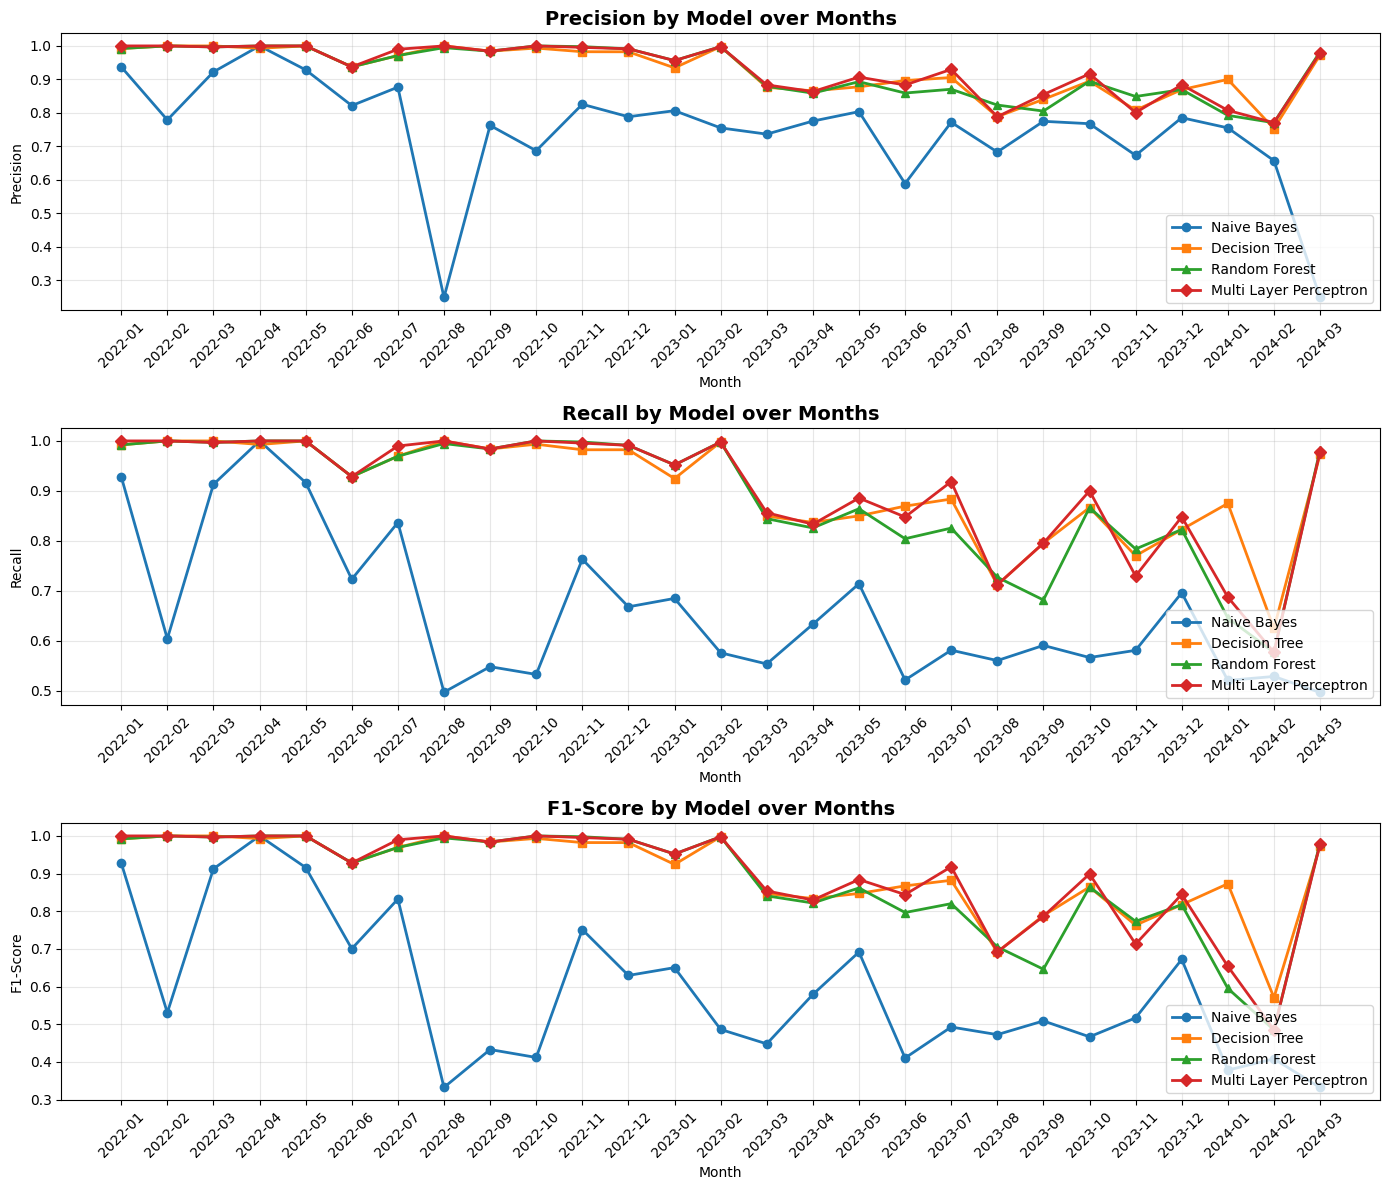


Chart saved to monthly_metrics_comparison.png


In [7]:
# 绘制不同模型在不同月份的指标折线图
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 获取所有模型名称
model_names = results_df['Model'].unique()
months = results_df['Month'].unique()

# 创建3个子图
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
markers = ['o', 's', '^', 'D']

# 图1: Precision
for idx, model_name in enumerate(model_names):
    model_data = results_df[results_df['Model'] == model_name]
    axes[0].plot(model_data['Month'], model_data['Precision'], 
                 marker=markers[idx], color=colors[idx], 
                 linewidth=2, markersize=6, label=model_name)
axes[0].set_title('Precision by Model over Months', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Precision')
axes[0].legend(loc='lower right')
axes[0].set_xticks(range(0, len(months)))
axes[0].set_xticklabels([months[i] for i in range(0, len(months))], rotation=45)
axes[0].grid(True, alpha=0.3)
# axes[0].set_ylim(0.8, 1.0)

# 图2: Recall
for idx, model_name in enumerate(model_names):
    model_data = results_df[results_df['Model'] == model_name]
    axes[1].plot(model_data['Month'], model_data['Recall'], 
                 marker=markers[idx], color=colors[idx], 
                 linewidth=2, markersize=6, label=model_name)
axes[1].set_title('Recall by Model over Months', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Recall')
axes[1].legend(loc='lower right')
axes[1].set_xticks(range(0, len(months)))
axes[1].set_xticklabels([months[i] for i in range(0, len(months))], rotation=45)
axes[1].grid(True, alpha=0.3)
# axes[1].set_ylim(0.8, 1.0)

# 图3: F1-Score
for idx, model_name in enumerate(model_names):
    model_data = results_df[results_df['Model'] == model_name]
    axes[2].plot(model_data['Month'], model_data['F1'], 
                 marker=markers[idx], color=colors[idx], 
                 linewidth=2, markersize=6, label=model_name)
axes[2].set_title('F1-Score by Model over Months', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('F1-Score')
axes[2].legend(loc='lower right')
axes[2].set_xticks(range(0, len(months)))
axes[2].set_xticklabels([months[i] for i in range(0, len(months))], rotation=45)
axes[2].grid(True, alpha=0.3)
# axes[2].set_ylim(0.8, 1.0)

plt.tight_layout()
plt.savefig('/Data2/hxq/MalGuard/model_training/monthly_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved to monthly_metrics_comparison.png")

In [ ]:
# 分析几个性能下降明显的点，random forest模型，2023-09，2024-01，2024-02，2024-09
